#Lab 5: Linear Regression — Predicting House Prices

**Name:** _Totaram_

**Program:** _BS(CS-V) Sec-G_

**CMS-ID:** _023-24-0244_

**GitHub Repository:** _https://github.com/totaramrathore/machine_learning_practical_
**Kaggle Submission:** _https://www.kaggle.com/totaramsarangani/competitions_

**The Soul of the Lab:**

We have information about houses, and we want to learn a mathematical relationship between those house characteristics and their selling prices.

##Part 1 — Dataset, Problem & Feature/Target Identification

**Tasks**

1. Load the dataset and briefly inspect it (shape, dtypes, first few rows, summary statistics).
2. Identify the dependent variable and list the independent variables, split explicitly into numerical features and
categorical features.
3. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that
changes about how you'll evaluate the model later.

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
# --- Load and inspect the dataset ---

df = pd.read_csv("train.csv")

print("Dataset shape:\n", df.shape)

print("\nFirst five rows:")
display(df.head())

print("\nDataset Information:")
df.info()

print("\nDataset statistics:")
display(df.describe())

Dataset shape:
 (1460, 81)

First five rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null  

,Id,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
count,1460.000000,1460.000000,1201.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1452.000000,1460.000000,...,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000,1460.000000
mean,730.500000,56.897260,70.049958,10516.828082,6.099315,5.575342,1971.267808,1984.865753,103.685262,443.639726,...,94.244521,46.660274,21.954110,3.409589,15.060959,2.758904,43.489041,6.321918,2007.815753,180921.195890
std,421.610009,42.300571,24.284752,9981.264932,1.382997,1.112799,30.202904,20.645407,181.066207,456.098091,...,125.338794,66.256028,61.119149,29.317331,55.757415,40.177307,496.123024,2.703626,1.328095,79442.502883
min,1.000000,20.000000,21.000000,1300.000000,1.000000,1.000000,1872.000000,1950.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,2006.000000,34900.000000
25%,365.750000,20.000000,59.000000,7553.500000,5.000000,5.000000,1954.000000,1967.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,5.000000,2007.000000,129975.000000
50%,730.500000,50.000000,69.000000,9478.500000,6.000000,5.000000,1973.000000,1994.000000,0.000000,383.500000,...,0.000000,25.000000,0.000000,0.000000,0.000000,0.000000,0.000000,6.000000,2008.000000,163000.000000
75%,1095.250000,70.000000,80.000000,11601.500000,7.000000,6.000000,2000.000000,2004.000000,166.000000,712.250000,...,168.000000,68.000000,0.000000,0.000000,0.000000,0.000000,0.000000,8.000000,2009.000000,214000.000000
max,1460.000000,190.000000,313.000000,215245.000000,10.000000,9.000000,2010.000000,2010.000000,1600.000000,5644.000000,...,857.000000,547.000000,552.000000,508.000000,480.000000,738.000000,15500.000000,12.000000,2010.000000,755000.000000


**=> Dependent variable, and Independent variables:**

Independent variables:
X → characteristics of the house

1. Numerical features:

    1. OverallQual
    2. GrLivArea
    3. TotalBsmtSF
    4. GarageCars
    5. YearBuilt
    6. FullBath
    7. 1stFlrSF
2. Categorical features:
    1. Neighborhood
    2. HouseStyle
    3. KitchenQual
    4. ExterQual
    5. GarageType

Dependent variable:
y → SalePrice

    1. SalePrice


In [9]:
# --- Identify dependent and independent variables ---

num_features = [
    "OverallQual",
    "GrLivArea",
    "TotalBsmtSF",
    "GarageCars",
    "YearBuilt",
    "FullBath",
    "1stFlrSF"
]

cat_features = [
    "Neighborhood",
    "HouseStyle",
    "KitchenQual",
    "ExterQual",
    "GarageType"
]

features = num_features + cat_features

X = df[features]
y = df["SalePrice"]

**=> Why is this regression?**

This is a regression problem because SalePrice is a continuous numerical target rather than a class label. Therefore, we evaluate the model using regression metrics such as MAE, MSE, RMSE, and R² instead of classification accuracy.

##Part 2 — Data Preparation & Train/Test Split

**Tasks**

4. Prepare X (features) and y (price) for modeling: encode every categorical column into numeric form, and briefly
justify your choice of encoding method for each type of column.
5. Confirm X is fully numeric with no missing values.
6. Split X and y into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [10]:
# --- preprocessing pipeline ---

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median"))
])

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(
        handle_unknown="ignore",
        drop="first"
    ))
])

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

**Why Pipeline?**

The important idea is that preprocessing becomes part of the model workflow.

Data -> Imputation -> Encoding -> Regression

This also lets us fit preprocessing using the training data and then apply the same learned transformation to unseen data.

In [11]:
# --- Confirm X is numerical and has no missing values ---

X_selected = df[features]

print("Missing values before preprocessing:")
print(X_selected.isnull().sum())

X_transformed = preprocessor.fit_transform(X_selected)

print("\nShape after preprocessing:", X_transformed.shape)
print("Missing values after preprocessing:",
      pd.DataFrame(X_transformed.toarray() if hasattr(X_transformed, "toarray")
                   else X_transformed).isnull().sum().sum())


Missing values before preprocessing:
OverallQual      0
GrLivArea        0
TotalBsmtSF      0
GarageCars       0
YearBuilt        0
FullBath         0
1stFlrSF         0
Neighborhood     0
HouseStyle       0
KitchenQual      0
ExterQual        0
GarageType      81
dtype: int64

Shape after preprocessing: (1460, 49)
Missing values after preprocessing: 0


For the selected 12 raw features, one categorical variable (GarageType) contains missing values, and the preprocessing pipeline handles them.

The model receives only numerical, non-missing values after preprocessing.

In [13]:
# --- train-test-split ---

from sklearn.model_selection import train_test_split

X = df[features]
y = df["SalePrice"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (1168, 12)
X_test : (292, 12)
y_train: (1168,)
y_test : (292,)


**Actual split:**

Training houses = 1168

Testing houses  = 292

The random_state=42 makes the split reproducible.

##Part 3 — Linear Regression & Predictions

**Tasks**

7. Train a LinearRegression model on the training data.
8. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10
test houses.

In [14]:
# --- Train Linear Regression ---

from sklearn.linear_model import LinearRegression

model = Pipeline([
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(X_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median'))]),
                                                  ['OverallQual', 'GrLivArea',
                                                   'TotalBsmtSF', 'GarageCars',
                                                   'YearBuilt', 'FullBath',
                                                   '1stFlrSF']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['Neighborhood', 'HouseStyle',
                                                   'KitchenQual', 'ExterQual',
                                                   'GarageType'])])),
                ('regressor', LinearRegression())])

In [16]:
# --- Generate predictions ---

y_pred = model.predict(X_test)

comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

display(comparison.head(10))

,Actual,Predicted
0,154500,140184.810375
1,325000,320500.103615
2,115000,113879.617729
3,159000,173975.716784
4,315500,306801.054154
5,75500,67375.873645
6,311500,241204.031188
7,146000,145282.802580
8,84500,67096.350953
9,135500,122591.619217


The purpose isn't that every prediction must exactly equal the actual price.

The purpose is to make the predictions as close as possible.

##Part 4 — Coefficients & Intercept

**Tasks**

9. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line,
plain-English interpretation for each feature (e.g. "each additional bathroom is associated with a price increase
of approximately ___, holding other features constant").
10. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [17]:
# --- Extract coefficients ---

fitted_preprocessor = model.named_steps["preprocessor"]
regressor = model.named_steps["regressor"]

feature_names = fitted_preprocessor.get_feature_names_out()

coefficient_table = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": regressor.coef_
})

display(coefficient_table)

,Feature,Coefficient
0,num__OverallQual,11385.780386
1,num__GrLivArea,72.822897
2,num__TotalBsmtSF,11.437732
3,num__GarageCars,14704.449605
4,num__YearBuilt,139.761346
5,num__FullBath,-994.339946
6,num__1stFlrSF,-29.396105
7,cat__Neighborhood_Blueste,-25531.846592
8,cat__Neighborhood_BrDale,-3666.243520
9,cat__Neighborhood_BrkSide,16680.375273


Important interpretation issue

Some transformed features are categorical dummy variables.

For example, Neighborhood_NoRidge has a coefficient of approximately:

+68,659

This does not mean:

"Being in NoRidge always adds $68,659."

It means approximately:

Holding the other selected features constant, a house in NoRidge is associated with about $68,659 higher predicted price than the reference neighborhood (Blmngtn).

This reference-category idea is extremely important.

For example:

GarageCars

Coefficient: 14,713.56

Interpretation:

Holding the other model features constant, one additional garage-car capacity is associated with approximately $14,714 higher predicted house price.

GrLivArea

Coefficient: 72.82

Interpretation:

Holding the other selected features constant, one additional unit of above-ground living area is associated with approximately $72.82 higher predicted price.

**Does the intercept make real-world sense?**

Our intercept is approximately:

−$277,366

The mathematical interpretation is:

Predicted SalePrice when every model feature equals zero.

But a real house cannot meaningfully have:

OverallQual = 0
GrLivArea = 0
YearBuilt = 0

Therefore, the intercept has little sensible real-world meaning for this dataset.

It is mainly the mathematical starting point of the regression equation.

##Part 5 — Residuals & Regression Metrics

**Tasks**

11. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of
residuals). Do the residuals look randomly scattered, or is there a visible pattern?
12. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
13. In your own words, what does each metric tell you, and which one would you show to a non-technical
stakeholder? Why?

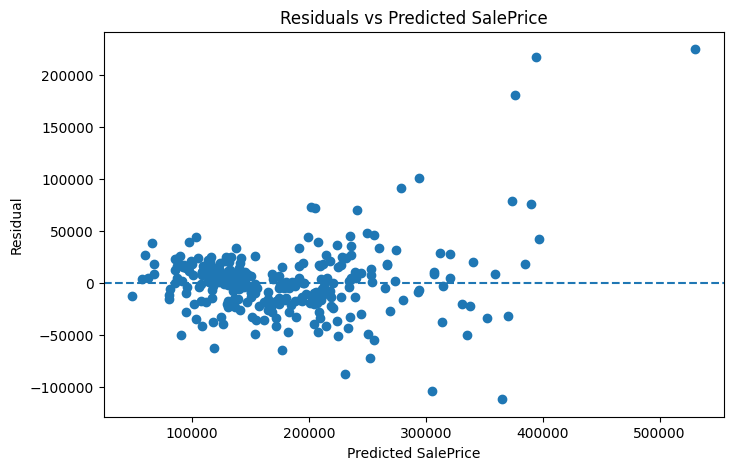

In [18]:
# --- Residual Analysis ---

import matplotlib.pyplot as plt

residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals)
plt.axhline(y=0, linestyle="--")
plt.xlabel("Predicted SalePrice")
plt.ylabel("Residual")
plt.title("Residuals vs Predicted SalePrice")
plt.show()

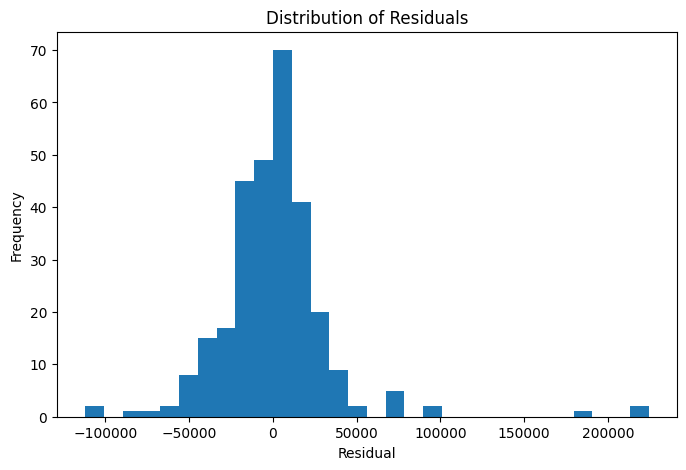

In [19]:
# --- histogram ---

plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30)
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.title("Distribution of Residuals")
plt.show()

We want residuals to be reasonably randomly scattered around zero.

If we see a systematic curve or increasing spread, that suggests the linear model is not completely capturing the underlying relationship.

For our actual model, the residuals are centered near zero, but they are not perfectly random. The residual-prediction correlation is about 0.20, and the residual distribution is noticeably right-skewed. This suggests some systematic structure remains that a simple linear model does not fully capture.

In [20]:
# --- MAE, MSE, RMSE and R² ---

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Value": [mae, mse, rmse, r2]
})

display(metrics)

,Metric,Value
0,MAE,2.115843e+04
1,MSE,1.161598e+09
2,RMSE,3.408223e+04
3,R²,8.485595e-01


**Explaining Metrcis in my own words:**

MAE  → average size of error

MSE  → squared error, punishes large errors

RMSE → error in original price units

R²   → proportion of variation explained


**For a non-technical stakeholder, I would show MAE.**

Why?

Because saying:

"The model's average absolute prediction error is approximately $21,157."

is much easier to understand than:

MSE = 1,161,460,823

or:

R² = 0.8486

RMSE is also highly useful, particularly because it is expressed in dollars, but MAE is generally the simplest direct stakeholder interpretation.

##Part 6 — Training vs. Testing & Generalization

**Tasks**

14. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Part 5 test-set
metrics in one comparison table.
15. Is there a large gap between training and testing performance? What would a large gap suggest about
overfitting or generalization, and what does your actual result suggest here?

In [21]:
# --- training metrics ---

train_pred = model.predict(X_train)

train_mae = mean_absolute_error(y_train, train_pred)
train_mse = mean_squared_error(y_train, train_pred)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, train_pred)

test_mae = mean_absolute_error(y_test, y_pred)
test_mse = mean_squared_error(y_test, y_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_pred)

comparison_metrics = pd.DataFrame({
    "Metric": ["MAE", "MSE", "RMSE", "R²"],
    "Training": [train_mae, train_mse, train_rmse, train_r2],
    "Testing": [test_mae, test_mse, test_rmse, test_r2]
})

display(comparison_metrics)

,Metric,Training,Testing
0,MAE,2.020855e+04,2.115843e+04
1,MSE,1.015898e+09,1.161598e+09
2,RMSE,3.187316e+04,3.408223e+04
3,R²,8.296773e-01,8.485595e-01


**Task 15 — Is there a large gap?**

Interestingly:

Training R² = 0.8297

Testing R²  = 0.8486

The test R² is actually slightly higher.

That means we do not see the typical large training-over-test performance gap associated with severe overfitting.

In fact:

Training MAE  ≈ $20,208
Testing MAE   ≈ $21,157

which is reasonably close.

So our actual result suggests:

The model generalizes reasonably well on this particular 80/20 split, and there is no evidence of severe overfitting from the train/test comparison.

However, we should not conclude that the model is "perfect." The model still has substantial prediction error, and residual analysis indicates that some structure remains unexplained.

##Part 7 — Final Model Analysis, Conclusion & Kaggle Submission

**Tasks**

16. Looking back at your Part 4 coefficient table, which 2–3 features appear most influential on price? Justify your
answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more
important feature if the underlying scales differ — discuss this briefly).
17. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices?
Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear
Regression have for this dataset? What would you try next?
18. Apply the same feature selection and encoding you used on train.csv to test.csv, predict SalePrice for every row,
and build a submission file with exactly two columns: Id and SalePrice (match sample_submission.csv's format).
Save it as submission.csv.
19. Submit submission.csv on the competition's "Submit Predictions" page. Record your public leaderboard score
and rank, and write 1–2 sentences on how it felt to see your model measured against thousands of other real
submissions.

**Task 16 — Most influential features**

Neighborhood categories produce some of the largest raw coefficient shifts, while among the numerical variables, GarageCars and OverallQual have relatively large per-unit effects. However, raw coefficient magnitude must be interpreted in light of each feature's scale and the reference category used for categorical variables.

**Task 17 — Final interpretation**

The Linear Regression model provides a reasonably strong baseline for predicting house prices using the selected numerical and categorical features. On the test set, the model achieved an R² of approximately 0.849, meaning that it explains a substantial portion of the variation in SalePrice for this split. The MAE was approximately $21,157, which is the most straightforward metric for communicating the typical absolute prediction error to a non-technical stakeholder. Among the numerical variables, GarageCars and OverallQual had relatively large coefficients, while some Neighborhood categories produced even larger coefficient shifts relative to the reference neighborhood. The intercept does not have a useful real-world interpretation because a house with all selected features equal to zero is not realistic. Although the training and testing results are reasonably close and do not indicate severe overfitting, the residual analysis shows that the linear model does not capture every pattern in house prices. A useful next step would be to apply stronger feature engineering, transform skewed variables, and compare Linear Regression with models such as Random Forest or other nonlinear regression methods.


In [22]:
# --- Create submission.csv ---

X_full = df[features]
y_full = df["SalePrice"]

test_df = pd.read_csv("test.csv")
X_kaggle = test_df[features]

final_model = Pipeline([
    ("preprocessor", ColumnTransformer([
        ("num", SimpleImputer(strategy="median"), num_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ))
        ]), cat_features)
    ])),
    ("regressor", LinearRegression())
])

final_model.fit(X_full, y_full)

kaggle_predictions = final_model.predict(X_kaggle)

submission = pd.DataFrame({
    "Id": test_df["Id"],
    "SalePrice": kaggle_predictions
})

submission.to_csv("submission.csv", index=False)

print("Submission created successfully.")
print("Rows:", len(submission))
print("Columns:", list(submission.columns))

display(submission.head())

Submission created successfully.
Rows: 1459
Columns: ['Id', 'SalePrice']


,Id,SalePrice
0,1461,115630.804318
1,1462,160635.430282
2,1463,163690.481574
3,1464,181355.171873
4,1465,252062.486556
